# 05 - Log-Gaussian Cox Processes (Latent-Rate Models)

Hawkes processes explain clustering through **self-excitation**: past events
cause future ones. But clustering can instead come from a fluctuating
*external* rate that events merely sample -- think a neuron driven by a slow
network oscillation. A **Log-Gaussian Cox Process (LGCP)** models exactly this:

$$\log \lambda(t) \sim \text{Gaussian process}, \qquad
  \text{events} \mid \lambda \sim \text{Poisson}(\lambda).$$

It is *doubly stochastic*: the rate is random, and events are Poisson given
the rate. This notebook contrasts the two clustering mechanisms and gives a
decision guide for choosing between them.

*Builds on 01.*

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import intensify as it

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

rng = np.random.default_rng(0)
print(f"intensify {it.__version__}")

intensify 0.3.3


## 1. Simulate a latent firing rate
intensify discretises the latent log-rate on a grid of `n_bins`; `mu_prior`
and `sigma_prior` set the mean and volatility of the Gaussian process on the
log scale. The realised `log_lambda` grid is the (normally unobserved) rate
that generated the spikes.

In [2]:
T = 12.0  # seconds
lgcp = it.LogGaussianCoxProcess(n_bins=80, mu_prior=1.5, sigma_prior=0.7)
spikes = np.asarray(lgcp.simulate(T=T, seed=4))
lgcp.set_last_window(T)

print(f"{len(spikes)} spikes over {T:.0f}s  (mean rate {len(spikes)/T:.1f} Hz)")
print(f"prior median rate exp(mu_prior) = {np.exp(1.5):.1f} Hz")

74 spikes over 12s  (mean rate 6.2 Hz)
prior median rate exp(mu_prior) = 4.5 Hz


## 2. Latent rate and the spikes it produced

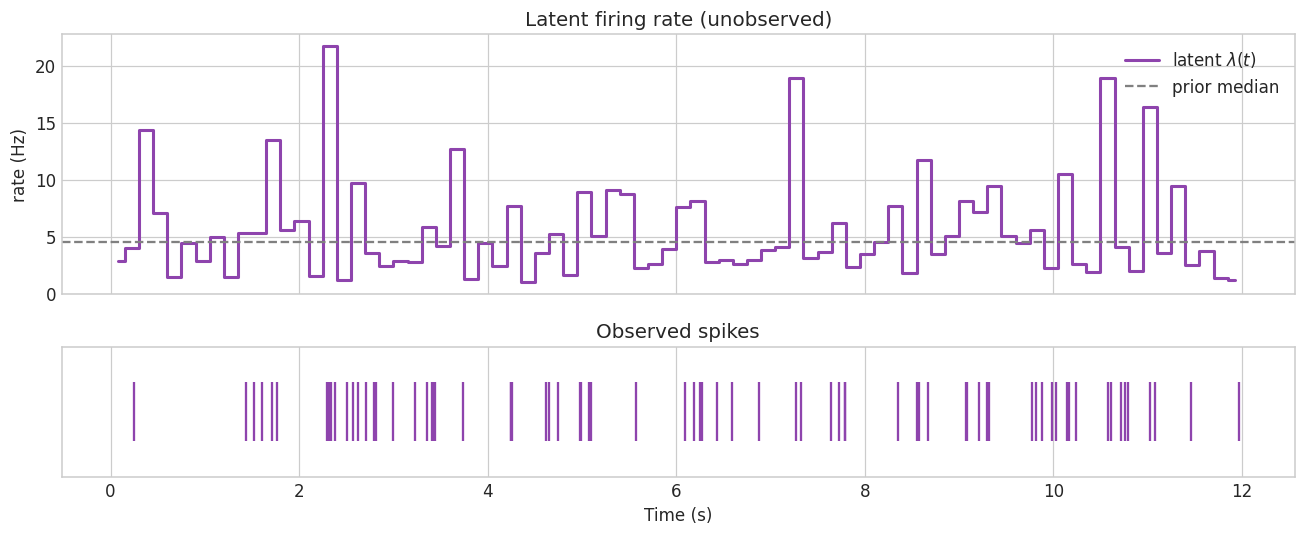

In [3]:
edges, mids = lgcp._make_bins(T)
rates = np.exp(np.asarray(lgcp.log_lambda, dtype=float))

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].step(mids, rates, where="mid", color="#8e44ad", lw=2, label=r"latent $\lambda(t)$")
axes[0].axhline(np.exp(1.5), color="gray", ls="--", label="prior median")
axes[0].set_ylabel("rate (Hz)"); axes[0].set_title("Latent firing rate (unobserved)")
axes[0].legend()
axes[1].eventplot(spikes, lineoffsets=0, linelengths=0.8, color="#8e44ad")
axes[1].set_yticks([]); axes[1].set_xlabel("Time (s)"); axes[1].set_title("Observed spikes")
fig.tight_layout(); plt.show()

## 3. Doubly stochastic = overdispersion

Because the rate itself varies, spike *counts* in fixed windows are more
variable than Poisson (where variance = mean). Larger `sigma_prior` means a
wigglier rate and stronger overdispersion. We quantify it with the Fano factor
(variance/mean of bin counts), which is 1 for a homogeneous Poisson process.

In [4]:
def fano(sigma, seed):
    m = it.LogGaussianCoxProcess(n_bins=120, mu_prior=1.5, sigma_prior=sigma)
    sp = np.asarray(m.simulate(T=60.0, seed=seed))
    counts, _ = np.histogram(sp, bins=np.arange(0, 61, 1.0))  # 1 s windows
    return counts.var() / counts.mean()

for sigma in (0.1, 0.5, 1.0):
    f = np.mean([fano(sigma, s) for s in range(5)])
    print(f"sigma_prior={sigma:.1f}  ->  Fano factor ~ {f:.2f}  (Poisson = 1.0)")

sigma_prior=0.1  ->  Fano factor ~ 0.91  (Poisson = 1.0)
sigma_prior=0.5  ->  Fano factor ~ 1.62  (Poisson = 1.0)
sigma_prior=1.0  ->  Fano factor ~ 6.56  (Poisson = 1.0)


## 4. Conditional likelihood
Given a latent rate grid, the LGCP reduces to independent Poisson counts per
bin, so its conditional log-likelihood is available directly.

In [5]:
ll = lgcp.log_likelihood(spikes, T)
print(f"conditional log-likelihood (given latent rate): {ll:.1f}")

conditional log-likelihood (given latent rate): 42.6


## 5. Hawkes vs LGCP: same clustering, different cause

Both models produce clustered spike trains, so eyeballing a raster is not
enough. The distinguishing question is *mechanistic*:

| Question | Reach for |
|---|---|
| Do events **trigger** more events? | **Hawkes** (self-excitation, `branching_ratio_`) |
| Is there a shared **latent drive**? | **LGCP** (doubly stochastic rate) |
| Is there **inhibition / refractoriness**? | **Nonlinear Hawkes** (notebook 04) |
| Is the rate a known **external function**? | **InhomogeneousPoisson** |

We simulate one of each and compare their inter-event interval signatures.

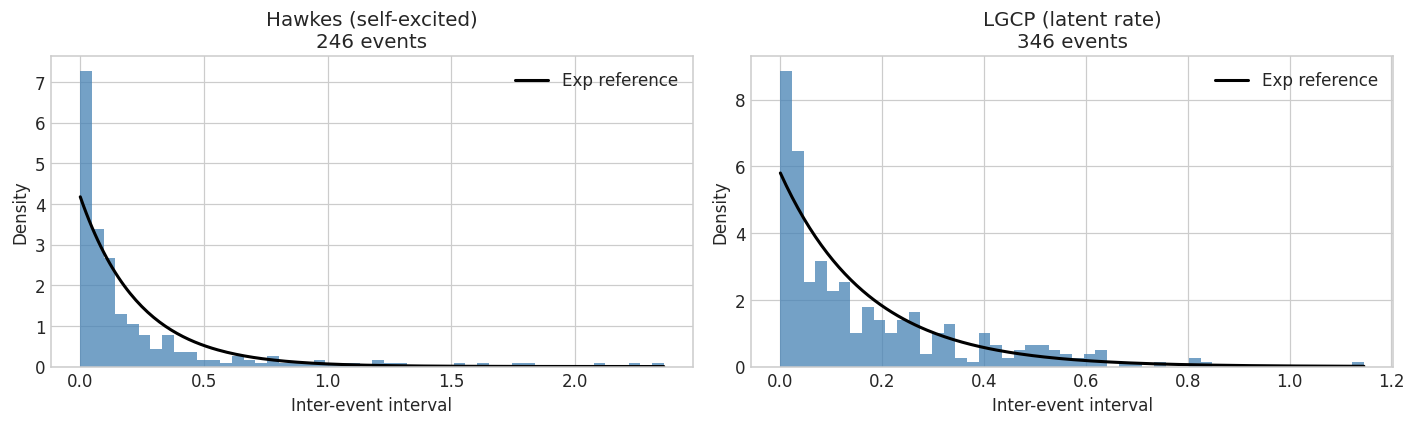

Both cluster, but only the Hawkes mechanism implies event-to-event causation.


In [6]:
hawkes = it.UnivariateHawkes(mu=2.0, kernel=it.ExponentialKernel(alpha=0.6, beta=8.0))
sp_hawkes = np.asarray(hawkes.simulate(T=60.0, seed=1))
sp_lgcp = np.asarray(it.LogGaussianCoxProcess(n_bins=200, mu_prior=1.5, sigma_prior=0.8)
                     .simulate(T=60.0, seed=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sp, name in [(axes[0], sp_hawkes, "Hawkes (self-excited)"),
                     (axes[1], sp_lgcp, "LGCP (latent rate)")]:
    it.plot_inter_event_intervals(sp, ax=ax, bins=50)
    ax.set_title(f"{name}\n{len(sp)} events")
fig.tight_layout(); plt.show()
print("Both cluster, but only the Hawkes mechanism implies event-to-event causation.")

## 6. Trial-aligned analysis (PSTH)

A staple of neuroscience: when a stimulus is repeated, align spikes to each
onset and histogram them to recover the average stimulus-driven rate. Here we
use `InhomogeneousPoisson` (a known deterministic rate) to mimic an evoked
response, then build a peri-stimulus time histogram with
`plot_event_aligned_histogram`.

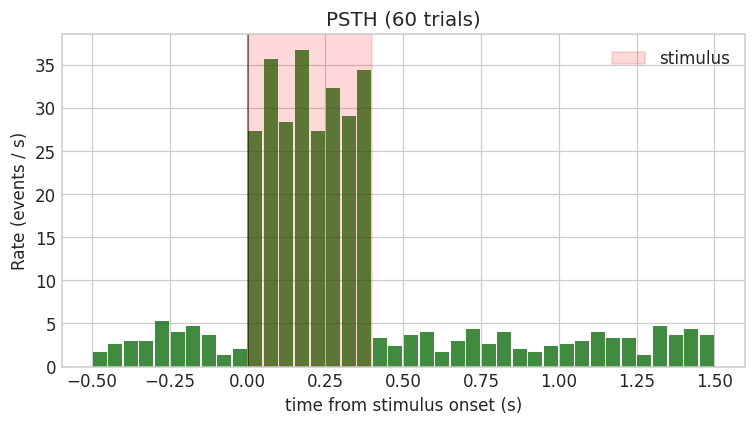

In [7]:
stim = it.InhomogeneousPoisson(rates={0.0: 3.0, 1.0: 30.0, 1.4: 3.0})  # baseline/evoked/baseline
n_trials, T_trial = 60, 3.0
all_spikes, onsets = [], []
for k in range(n_trials):
    off = k * T_trial
    all_spikes.append(np.asarray(stim.simulate(T=T_trial, seed=200 + k)) + off)
    onsets.append(off + 1.0)  # stimulus at t=1 within each trial
all_spikes = np.concatenate(all_spikes); onsets = np.array(onsets)

fig = it.plot_event_aligned_histogram(all_spikes, reference_times=onsets,
                                      window=(-0.5, 1.5), bin_width=0.05)
ax = fig.axes[0]
ax.axvspan(0.0, 0.4, alpha=0.15, color="red", label="stimulus")
ax.set_xlabel("time from stimulus onset (s)"); ax.set_title("PSTH (60 trials)")
ax.legend(); plt.show()

## A note on inference

This release exposes LGCP **simulation** and the **conditional** likelihood;
fitting the latent field from spikes (variational/MCMC inference of
`log_lambda`) is **not yet wired into** `LogGaussianCoxProcess.fit`. For
*parametric* point processes (Hawkes family) use `method="mle"`, and for
Bayesian posteriors use `method="bayesian"` (notebook 04). If you need a
latent-rate fit today, model the rate explicitly with
`InhomogeneousPoisson`.

---
### Try it yourself
* Sweep `sigma_prior` and trace the Fano factor -- the overdispersion curve.
* Compare a Hawkes fit's `branching_ratio_` on LGCP-generated data: latent-rate
  clustering can masquerade as weak self-excitation.
* Replace the boxcar evoked rate with a smooth bump and re-derive the PSTH.

### Where to next
* Full domain walk-throughs in `examples/`:
  `neuroscience_spike_analysis`, `seismology_aftershocks`,
  `biology_epidemiology_ecology`.
* User guide: [simulation](../docs/user_guide/simulation.md),
  [diagnostics](../docs/user_guide/diagnostics.md).